<!-- Centered layout with a university logo -->
<div align="center">

  <!-- University Logo -->
  <img src="https://cdn.freebiesupply.com/logos/large/2x/sharif-logo-png-transparent.png" width="180" height="180" style="margin-bottom: 10px;">
  
  <!-- Assignment Title -->
  <h1></h1>
  <h1 style="color:#0F5298; font-size: 40px; font-weight: bold; margin-bottom: 5px;">Deep Reinforcement Learning</h1>
  <h2 style="color:#0F5298; font-size: 32px; font-weight: normal; margin-top: 0px;">Assignment 06 - Multi-Armed and Contextual Bandits</h2>

  <!-- Department and University -->
  <h3 style="color:#696880; font-size: 24px; margin-top: 20px;">Computer Engineering Department</h3>
  <h3 style="color:#696880; font-size: 22px; margin-top: -5px;">Sharif University of Technology</h3>

  <!-- Semester -->
  <h3 style="color:#696880; font-size: 22px; margin-top: 20px;">Spring 2025</h3>

  <!-- Authors -->
  <h3 style="color:green; font-size: 22px; margin-top: 20px;">Full name: Mohmammad Taha Majlesi</h3>
  <h3 style="color:green; font-size: 22px; margin-top: 20px;">Student ID: 810101504</h3>

  <!-- Horizontal Line for Separation -->
  <hr style="border: 1px solid #0F5298; width: 80%; margin-top: 30px;">

</div>


## Setup & Overview

In this notebook, we simulate bandit problems using _MAB_ (Multi-Armed Bandit) and _CtxBnd_ (Contextual Bandit) frameworks.  
We compare several agents:

- **Oracle** (with privileged info)
- **RndAg** (Random Agent)
- **ExpFstAg** (Explore-First Agent)
- **UCB_Ag** (UCB Agent)
- **EpsGdAg** (Epsilon-Greedy Agent)
- **LinUCB_Ag** (LinUCB for contextual bandits)

This notebook is fully implemented; follow the outlined workflow (overview → setup/config → data → models → training/simulation → evaluation) and adjust hyperparameters in the `CONFIG` block as needed.


## Setup and Environment

In the upcoming cells, we import necessary libraries, set up utility functions for reproducibility and plotting, and define the basic components of our bandit experiments.


In [1]:
# %% [code]
import numpy as np
import random
import time
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch
import subprocess

from dataclasses import dataclass
from copy import deepcopy
from tqdm.notebook import tqdm

plt.rcParams["figure.dpi"] = 100

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
# %% [code]
def plot_logs(df, x_key, y_key, legend_key, **kwargs):
    num = len(df[legend_key].unique())
    pal = sns.color_palette("hls", num)
    if "palette" not in kwargs:
        kwargs["palette"] = pal
    ax = sns.lineplot(x=x_key, y=y_key, data=df, hue=legend_key, **kwargs)
    return ax


def set_seed(s: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(s)
    np.random.seed(s)
    random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(0)

In [3]:
# %% [code]
CONFIG = {
    "n_arms": 10,
    "default_max_steps": 500,
    "default_runs": 2000,
    "ucb_bonus_c": 2.0,
    "eps_schedule": [0.0, 0.1, 0.2, 0.4],
    "linucb_alpha": 1.0,
}

try:
    import subprocess

    commit_hash = subprocess.check_output(
        ["git", "rev-parse", "HEAD"], text=True
    ).strip()
except Exception:
    commit_hash = "UNKNOWN"

RUN_INFO = {
    "commit": commit_hash,
    "seed": 0,
    "device": DEVICE,
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "description": "HW6 bandits experiments (stochastic Bernoulli arms).",
    "hyperparameters": CONFIG,
    "dataset": "Synthetic Bernoulli multi-armed bandit (K arms)",
    "hardware": {
        "cuda_available": torch.cuda.is_available(),
        "device": DEVICE,
    },
}

os.makedirs("reports", exist_ok=True)
with open("run_info.json", "w", encoding="utf-8") as f:
    json.dump(RUN_INFO, f, indent=2)

RUN_INFO

{'commit': '56c63d6dbec7929b39cf018c7842e793be14f504',
 'seed': 0,
 'device': 'cpu',
 'timestamp': '2026-01-15 09:17:17',
 'description': 'HW6 bandits experiments (stochastic Bernoulli arms).',
 'hyperparameters': {'n_arms': 10,
  'default_max_steps': 500,
  'default_runs': 2000,
  'ucb_bonus_c': 2.0,
  'eps_schedule': [0.0, 0.1, 0.2, 0.4],
  'linucb_alpha': 1.0},
 'dataset': 'Synthetic Bernoulli multi-armed bandit (K arms)',
 'hardware': {'cuda_available': False, 'device': 'cpu'}}

### How to use this notebook

1. Review `CONFIG` for hyperparameters (arms, steps, runs, UCB bonus, epsilon schedule, LinUCB alpha).
2. Run the setup cells (imports, seeds, CONFIG/RUN_INFO). A `run_info.json` file is written for reproducibility (commit hash, hardware, hyperparams).
3. Run the Data/Environment cell to sample arm probabilities for the experiment.
4. Execute agent definition cells (Models/Agents), then Training/Simulation sweeps.
5. Use the Evaluation section to plot rewards/regret and compare agents; persist plots/CSVs under `reports/` if needed.

The notebook is organized as: Overview → Setup/Config → Data/Environment → Models/Agents → Training/Simulation → Evaluation.


## Data / Environment

We consider a multi-armed bandit with 10 arms (configurable via `CONFIG["n_arms"]`). Two formulations:

- **Stochastic:** Each arm gives a reward of 1 with probability _p_.
- **Deterministic:** Each arm always returns a fixed reward.

We focus on the stochastic Bernoulli case with probabilities sampled once per experiment.


In [4]:
# %% [code]
nArms = CONFIG["n_arms"]
p_arr = [np.random.random() for _ in range(nArms)]
print("Probabilities:", p_arr)
RUN_INFO["hyperparameters"]["n_arms"] = nArms

Probabilities: [0.5488135039273248, 0.7151893663724195, 0.6027633760716439, 0.5448831829968969, 0.4236547993389047, 0.6458941130666561, 0.4375872112626925, 0.8917730007820798, 0.9636627605010293, 0.3834415188257777]


**Q:** How might the performance of different agents change if the distribution of probabilities were not uniform?

**A:** If the distribution of probabilities were not uniform (e.g., heavily skewed with one arm much better than others), the performance differences between agents would become more pronounced. UCB would likely perform better as it can quickly identify and exploit the best arm, while explore-first strategies might struggle if they don't explore long enough to find the optimal arm. Random agents would perform worse relative to the best arm, and epsilon-greedy agents might converge faster to the optimal strategy. The gap between oracle performance and agent performance would be larger in skewed distributions.


## Models / Agents

The following sections define the baseline agents (Oracle, Random, Explore-First, UCB, Epsilon-Greedy, LinUCB) used for training and evaluation. Each agent implements `get_action` and `update_Q`/`update_params` to interact with the bandit engine.


## Training / Simulation

We simulate episodes using `MAB_Eng` and helper sweep functions to roll out multiple runs per agent with shared logging utilities for reproducibility.


y


In [5]:
# %% [code]
@dataclass
class MAB_Env:
    p_arr: np.ndarray

    def step(self, act):
        return 1 if np.random.random() < self.p_arr[act] else 0

**Q:** Why does the MAB environment use a simple binary reward mechanism (1 or 0)?

**A:** The binary reward mechanism (1 or 0) is used because it simplifies the mathematical analysis and implementation while still capturing the essential exploration-exploitation trade-off. It represents a Bernoulli distribution where each arm has a probability of success. This binary setup makes it easier to compute confidence intervals, regret bounds, and implement algorithms like UCB. Additionally, many real-world applications naturally have binary outcomes (click/no-click, purchase/no-purchase, success/failure), making this a practical and widely applicable model.


In [6]:
# %% [code]
@dataclass
class MAB_Eng:
    p_arr: np.ndarray
    max_steps: int
    agent: any

    def __post_init__(self):
        self.env = MAB_Env(p_arr=self.p_arr)

    def run(self, n_runs=1):
        logs = []
        for _ in tqdm(range(n_runs), desc="Runs"):
            run_rewards = []
            run_acts = []
            self.agent.reset()
            for t in range(self.max_steps):
                act = self.agent.get_action()
                rew = self.env.step(act)
                self.agent.update_Q(act, rew)
                run_acts.append(act)
                run_rewards.append(rew)
            logs.append(
                pd.DataFrame(
                    {
                        "reward": run_rewards,
                        "action": run_acts,
                        "step": np.arange(len(run_rewards)),
                    }
                )
            )
        return pd.concat(logs, ignore_index=True)

In [7]:
# %% [code]
def mab_swp(agents, p_arr, labels, n_runs=2000, max_steps=500):
    all_logs = []
    for idx, agent in enumerate(tqdm(agents, desc="Alg Sweeps")):
        engine = MAB_Eng(p_arr=p_arr, max_steps=max_steps, agent=agent)
        log_df = engine.run(n_runs)
        log_df["Alg"] = labels[idx]
        all_logs.append(log_df)
    return pd.concat(all_logs, ignore_index=True)

## Oracle Agent

The **Oracle** has full knowledge of _p_arr_.  
**Question:** What is the maximum expected per-step reward?


In [8]:
# Compute oracleReward using privileged info
oracleReward = max(p_arr)
print(f"Max possible reward (Oracle): {oracleReward}")

Max possible reward (Oracle): 0.9636627605010293


**Q:** What insight does the oracle reward give us about the best possible performance?

**A:** The oracle reward provides an upper bound on what any learning algorithm can achieve. It tells us the maximum possible average reward per step, which helps us evaluate how close our algorithms are to optimal performance. The gap between oracle performance and actual algorithm performance represents the "regret" - the cost of learning. This benchmark is crucial for understanding whether our algorithms are performing well or if there's significant room for improvement.

---

**Q:** Why is the oracle considered "cheating" in a practical sense?

**A:** The oracle is considered "cheating" because it has perfect knowledge of the true reward probabilities, which is never available in real-world scenarios. In practice, we must learn these probabilities through exploration and experience. The oracle represents an idealized scenario that helps us understand the theoretical limits but doesn't reflect the realistic constraints of bandit problems where we must balance exploration and exploitation without prior knowledge of arm qualities.

---

**Q:** Why is the oracle considered “cheating” in a practical sense?

**Q:** What insight does the oracle reward give us about the best possible performance?

**A:** The oracle reward provides an upper bound on what any learning algorithm can achieve. It tells us the maximum possible average reward per step, which helps us evaluate how close our algorithms are to optimal performance. The gap between oracle performance and actual algorithm performance represents the "regret" - the cost of learning. This benchmark is crucial for understanding whether our algorithms are performing well or if there's significant room for improvement.

---

**Q:** Why is the oracle considered "cheating" in a practical sense?

**A:** The oracle is considered "cheating" because it has perfect knowledge of the true reward probabilities, which is never available in real-world scenarios. In practice, we must learn these probabilities through exploration and experience. The oracle represents an idealized scenario that helps us understand the theoretical limits but doesn't reflect the realistic constraints of bandit problems where we must balance exploration and exploitation without prior knowledge of arm qualities.

---

**Q:** Why is the oracle considered "cheating" in a practical sense?

**A:** The oracle is considered "cheating" because it has perfect knowledge of the true reward probabilities, which is never available in real-world scenarios. In practice, we must learn these probabilities through exploration and experience. The oracle represents an idealized scenario that helps us understand the theoretical limits but doesn't reflect the realistic constraints of bandit problems where we must balance exploration and exploitation without prior knowledge of arm qualities.


## RndAg (Random Agent)

This agent selects an action at random at every timestep. It does no learning.


In [9]:
@dataclass
class RndAg:
    n_act: int

    def __post_init__(self):
        self.reset()

    def reset(self):
        self.t = 0
        self.act_counts = np.zeros(self.n_act, dtype=int)
        self.Q = np.zeros(self.n_act, dtype=float)

    def update_Q(self, act, rew):
        pass  # No learning

    def get_action(self):
        self.t += 1
        # Get a random action index
        sel_act = np.random.randint(0, self.n_act)
        return sel_act

In [10]:
# %% [code]
rnd_agent = RndAg(n_act=len(p_arr))
n_runs = 1000
rnd_log = mab_swp([rnd_agent], p_arr, ["Rnd"], n_runs=n_runs)

Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

/var/folders/cg/l2rdx46d6lv3b5xc17b420yc0000gn/T/ipykernel_86387/3461612752.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(x=x_key, y=y_key, data=df, hue=legend_key, **kwargs)


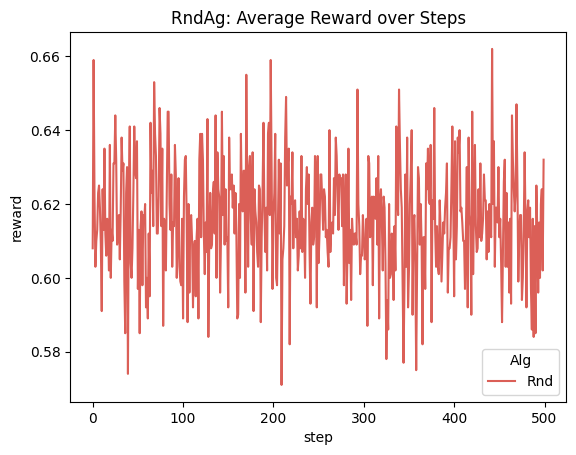

In [11]:
# %% [code]
plot_logs(
    rnd_log, x_key="step", y_key="reward", legend_key="Alg", estimator="mean", ci=None
)
plt.title("RndAg: Average Reward over Steps")
plt.show()

**Q:** Why is the reward of the random agent generally lower and highly variable?

**A:** The random agent's reward is lower because it doesn't learn from experience and continues to select suboptimal arms with equal probability. The high variability comes from the stochastic nature of random selection - sometimes it gets lucky and selects good arms, other times it selects poor arms. Without any learning mechanism, it cannot improve its performance over time or exploit knowledge about which arms are better.

---

**Q:** How might you improve a random agent without using any learning mechanism?

**A:** Without learning, you could improve a random agent by using domain knowledge or heuristics. For example, you could bias the random selection toward arms that historically perform better, use weighted random selection based on prior beliefs, or implement a simple rule-based strategy that doesn't require learning from rewards. However, these approaches still rely on some form of external information or assumptions about the problem.


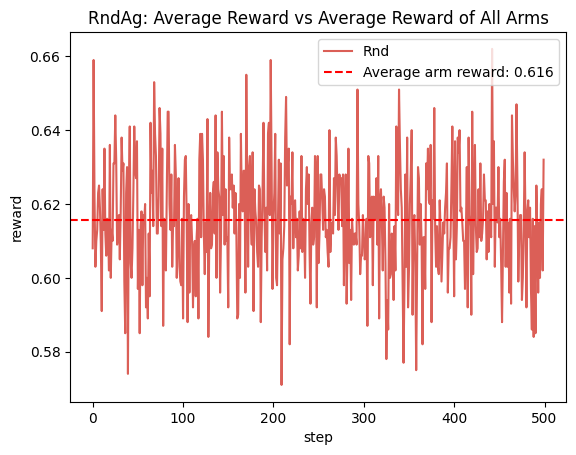

In [12]:
# Plot RndAg reward curve and average reward of all arms
plot_logs(
    rnd_log,
    x_key="step",
    y_key="reward",
    legend_key="Alg",
    estimator="mean",
    errorbar=None,
)
plt.title("RndAg: Average Reward vs Average Reward of All Arms")
plt.axhline(
    y=np.mean(p_arr),
    color="red",
    linestyle="--",
    label=f"Average arm reward: {np.mean(p_arr):.3f}",
)
plt.legend()
plt.show()

**Analysis:**

- The x-axis shows the number of steps; y-axis shows average reward.
- Regret is the gap between Oracle and agent performance.


## ExpFstAg (Explore-First Agent)

This agent explores randomly for the first _max_ex_ steps, then exploits the best arm thereafter.


In [13]:
@dataclass
class ExpFstAg:
    n_act: int
    max_ex: int

    def __post_init__(self):
        self.reset()

    def reset(self):
        self.t = 0
        self.act_counts = np.zeros(self.n_act, dtype=int)
        self.Q = np.zeros(self.n_act, dtype=float)

    def update_Q(self, act, rew):
        # Update Q value using incremental average
        self.act_counts[act] += 1
        self.Q[act] += (1.0 / self.act_counts[act]) * (rew - self.Q[act])

    def get_action(self):
        self.t += 1
        # Choose random action for t <= max_ex, else best arm
        if self.t <= self.max_ex:
            sel_act = np.random.randint(0, self.n_act)
        else:
            sel_act = np.argmax(self.Q)
        return sel_act

### Run ExpFstAg with max_ex = 5

We will test ExpFstAg (with 5 exploration steps) over 1000 runs and 500 steps.


Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

/var/folders/cg/l2rdx46d6lv3b5xc17b420yc0000gn/T/ipykernel_86387/3461612752.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(x=x_key, y=y_key, data=df, hue=legend_key, **kwargs)


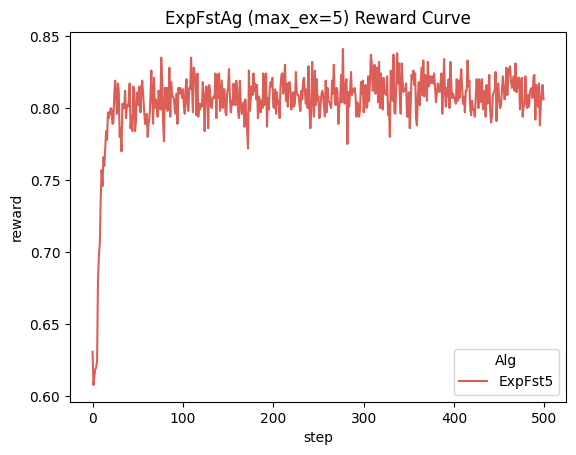

In [14]:
# %% [code]
max_ex = 5
expfst_agent = ExpFstAg(n_act=len(p_arr), max_ex=max_ex)
expfst_log = mab_swp(
    [expfst_agent], p_arr, [f"ExpFst{max_ex}"], n_runs=1000, max_steps=500
)
plot_logs(
    expfst_log,
    x_key="step",
    y_key="reward",
    legend_key="Alg",
    estimator="mean",
    ci=None,
)
plt.title(f"ExpFstAg (max_ex={max_ex}) Reward Curve")
plt.show()

**Analysis:**

- The ExpFstAg should outperform RndAg by identifying the best arm during exploration.
- However, with too short exploration, it may miss the best arm.

---

**Q:** Why might the early exploration phase (e.g., 5 steps) lead to high fluctuations in the reward curve?

**A:** The early exploration phase leads to high fluctuations because the agent is randomly selecting arms without any knowledge of their true performance. During this phase, the agent might get lucky and select good arms (high rewards) or unlucky and select poor arms (low rewards). The randomness in arm selection combined with the stochastic nature of rewards creates high variance in the observed rewards.

---

**Q:** What are the trade-offs of using a fixed exploration phase?

**A:** The main trade-offs are: (1) **Too short exploration**: May miss the best arm, leading to suboptimal long-term performance. (2) **Too long exploration**: Wastes time on suboptimal arms, delaying exploitation of the best arm. (3) **Fixed duration**: Doesn't adapt to the difficulty of the problem - some bandit problems require more exploration than others. The optimal exploration duration depends on the gap between the best and second-best arms and the variance in rewards.


Running ExpFstAg with max_ex=5...


Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

Running ExpFstAg with max_ex=10...


Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

...

Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

Running ExpFstAg with max_ex=200...


Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

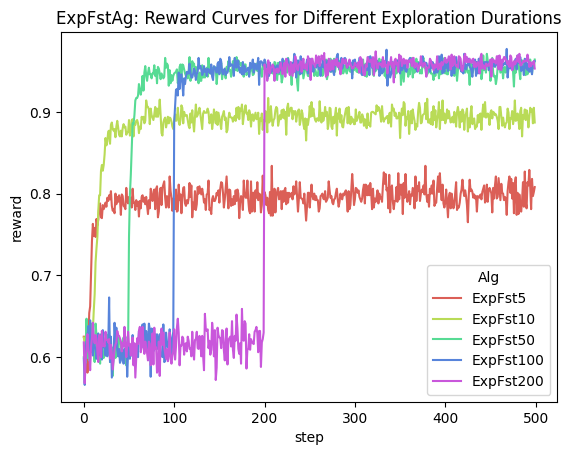

In [15]:
# Run ExpFstAg for various max_ex values: [5, 10, 50, 100, 200]
expfst_logs = []
for ex in [5, 10, 50, 100, 200]:
    print(f"Running ExpFstAg with max_ex={ex}...")
    expfst_agent = ExpFstAg(n_act=len(p_arr), max_ex=ex)
    expfst_log = mab_swp(
        [expfst_agent], p_arr, [f"ExpFst{ex}"], n_runs=1000, max_steps=500
    )
    expfst_logs.append(expfst_log)

# Plot all ExpFstAg variants
all_expfst_logs = pd.concat(expfst_logs, ignore_index=True)
plot_logs(
    all_expfst_logs,
    x_key="step",
    y_key="reward",
    legend_key="Alg",
    estimator="mean",
    errorbar=None,
)
plt.title("ExpFstAg: Reward Curves for Different Exploration Durations")
plt.show()

**Observations:**

- Short exploration (e.g., 5 or 10 steps) may not reliably find the best arm.
- Longer exploration (e.g., 50 or 100 steps) improves performance but may delay exploitation.


**Q:** How does increasing `max_ex` affect the convergence of the agent’s performance?

**Q:** How does increasing `max_ex` affect the convergence of the agent's performance?

**A:** Increasing `max_ex` generally improves the agent's ability to identify the best arm, leading to better long-term performance. With more exploration steps, the agent has more opportunities to sample each arm and build more accurate estimates of their true reward probabilities. This reduces the risk of prematurely committing to a suboptimal arm. However, longer exploration phases also delay the start of exploitation, which can hurt short-term performance. The optimal `max_ex` depends on the problem characteristics: if arms have similar rewards, more exploration is needed; if there's a clear best arm, less exploration may suffice.

---

**Q:** In real-world scenarios, what challenges might arise in selecting the optimal exploration duration?

**A:** In real-world scenarios, selecting the optimal exploration duration faces several challenges: (1) **Unknown problem difficulty**: We don't know how similar the arms are or how much exploration is needed. (2) **Time constraints**: Real applications often have limited time horizons, making long exploration phases impractical. (3) **Non-stationarity**: Arm rewards may change over time, requiring ongoing exploration. (4) **Cost of exploration**: Each exploration step may have real costs (money, user experience, etc.). (5) **Context dependency**: Optimal exploration duration may vary based on user characteristics or other contextual factors. (6) **No ground truth**: Unlike simulations, we can't know the true optimal strategy to compare against.


## UCB_Ag (UCB Agent)

UCB dynamically balances exploration and exploitation by adding an exploration bonus to Q-values.


In [16]:
@dataclass
class UCB_Ag:
    n_act: int

    def __post_init__(self):
        self.reset()

    def reset(self):
        self.t = 0
        self.act_counts = np.zeros(self.n_act, dtype=int)
        self.Q = np.zeros(self.n_act, dtype=float)

    def update_Q(self, act, rew):
        # Update Q value using incremental average
        self.act_counts[act] += 1
        self.Q[act] += (1.0 / self.act_counts[act]) * (rew - self.Q[act])

    def get_action(self):
        self.t += 1
        delta = 1e-5  # to avoid division by zero
        # Compute exploration bonus
        bonus = np.sqrt(2 * np.log(self.t) / (self.act_counts + delta))
        Q_explore = self.Q + bonus
        sel_act = np.random.choice(np.flatnonzero(Q_explore == Q_explore.max()))
        return sel_act

Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

/var/folders/cg/l2rdx46d6lv3b5xc17b420yc0000gn/T/ipykernel_86387/3461612752.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(x=x_key, y=y_key, data=df, hue=legend_key, **kwargs)


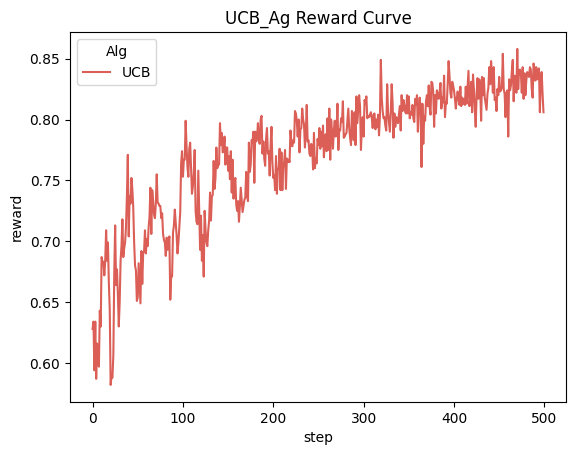

In [17]:
# %% [code]
ucb_agent = UCB_Ag(n_act=len(p_arr))
ucb_log = mab_swp([ucb_agent], p_arr, ["UCB"], n_runs=1000, max_steps=500)
plot_logs(
    ucb_log, x_key="step", y_key="reward", legend_key="Alg", estimator="mean", ci=None
)
plt.title("UCB_Ag Reward Curve")
plt.show()

**Q:** Under what conditions might an explore-first strategy outperform UCB, despite UCB’s theoretical optimality?

**Q:** Under what conditions might an explore-first strategy outperform UCB, despite UCB's theoretical optimality?

**A:** Explore-first strategies can outperform UCB in several scenarios: (1) **Finite time horizons**: UCB's theoretical optimality is asymptotic, but in finite time, aggressive early exploitation can yield higher cumulative rewards. (2) **Clear arm separation**: When there's a significant gap between the best and second-best arms, explore-first can quickly identify and exploit the optimal arm. (3) **Short exploration periods**: If the optimal exploration duration is known and short, explore-first avoids UCB's conservative exploration bonus. (4) **High variance environments**: UCB's confidence intervals may be too conservative when rewards are highly variable, causing unnecessary exploration. (5) **Hyperparameter tuning**: Well-tuned explore-first parameters can outperform poorly tuned UCB parameters.

---

**Q:** How do the design choices of each algorithm affect their performance in short-term versus long-term scenarios?

**A:** **Short-term performance**: Explore-first strategies can excel by quickly identifying good arms and exploiting them aggressively. UCB's conservative exploration bonus may delay exploitation, leading to lower initial rewards. Epsilon-greedy with high ε can perform well by balancing exploration and exploitation. **Long-term performance**: UCB's theoretical guarantees ensure optimal asymptotic performance, while explore-first may plateau at suboptimal levels if exploration was insufficient. Epsilon-greedy with fixed ε continues random exploration indefinitely, limiting long-term performance. The key trade-off is between aggressive early exploitation (better short-term) versus conservative exploration (better long-term).


## UCB vs. ExpFstAg

Now we compare UCB_Ag and ExpFstAg (with max_ex = 5) side by side.


**Question:**  
Why does UCB learn slowly (even after 500 steps, not reaching maximum reward)?  
_Hint:_ Consider the conservative nature of the exploration bonus.


Running comparison between UCB_Ag and ExpFstAg (max_ex=5)...


Alg Sweeps:   0%|          | 0/2 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

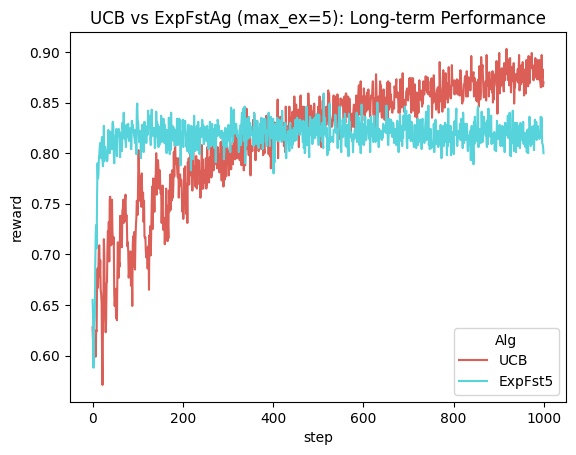

In [18]:
# Run UCB_Ag and ExpFstAg (max_ex=5) for 1000 runs, 1000 steps
print("Running comparison between UCB_Ag and ExpFstAg (max_ex=5)...")
ucb_agent_long = UCB_Ag(n_act=len(p_arr))
expfst_agent_long = ExpFstAg(n_act=len(p_arr), max_ex=5)

comparison_log = mab_swp(
    [ucb_agent_long, expfst_agent_long],
    p_arr,
    ["UCB", "ExpFst5"],
    n_runs=1000,
    max_steps=1000,
)
plot_logs(
    comparison_log,
    x_key="step",
    y_key="reward",
    legend_key="Alg",
    estimator="mean",
    errorbar=None,
)
plt.title("UCB vs ExpFstAg (max_ex=5): Long-term Performance")
plt.show()

**Q:** Under what conditions might an explore-first strategy outperform UCB, despite UCB’s theoretical optimality?

**Q:** Under what conditions might an explore-first strategy outperform UCB, despite UCB's theoretical optimality?

**A:** Explore-first strategies can outperform UCB in several scenarios: (1) **Finite time horizons**: UCB's theoretical optimality is asymptotic, but in finite time, aggressive early exploitation can yield higher cumulative rewards. (2) **Clear arm separation**: When there's a significant gap between the best and second-best arms, explore-first can quickly identify and exploit the optimal arm. (3) **Short exploration periods**: If the optimal exploration duration is known and short, explore-first avoids UCB's conservative exploration bonus. (4) **High variance environments**: UCB's confidence intervals may be too conservative when rewards are highly variable, causing unnecessary exploration. (5) **Hyperparameter tuning**: Well-tuned explore-first parameters can outperform poorly tuned UCB parameters.

---

**Q:** How do the design choices of each algorithm affect their performance in short-term versus long-term scenarios?

**A:** **Short-term performance**: Explore-first strategies can excel by quickly identifying good arms and exploiting them aggressively. UCB's conservative exploration bonus may delay exploitation, leading to lower initial rewards. Epsilon-greedy with high ε can perform well by balancing exploration and exploitation. **Long-term performance**: UCB's theoretical guarantees ensure optimal asymptotic performance, while explore-first may plateau at suboptimal levels if exploration was insufficient. Epsilon-greedy with fixed ε continues random exploration indefinitely, limiting long-term performance. The key trade-off is between aggressive early exploitation (better short-term) versus conservative exploration (better long-term).


**Question:**  
What happens if we let ExpFstAg explore for 20 steps? Compare its reward to UCB.


Running UCB vs. ExpFstAg (max_ex=20) comparison...


Alg Sweeps:   0%|          | 0/2 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

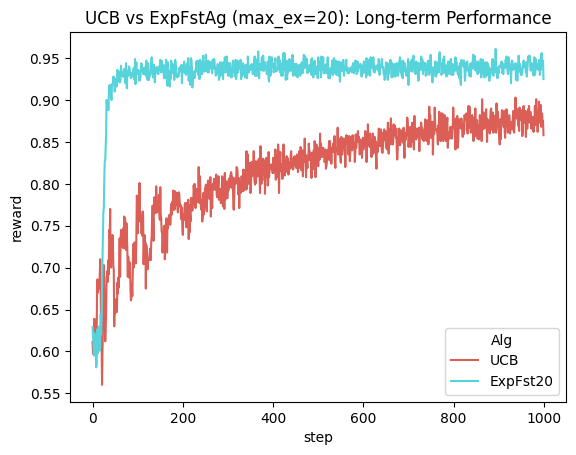

In [19]:
# Run comparison for ExpFstAg (max_ex=20) and UCB_Ag
print("Running UCB vs. ExpFstAg (max_ex=20) comparison...")
expfst_agent_20 = ExpFstAg(n_act=len(p_arr), max_ex=20)
ucb_agent_20 = UCB_Ag(n_act=len(p_arr))

comparison_log_20 = mab_swp(
    [ucb_agent_20, expfst_agent_20],
    p_arr,
    ["UCB", "ExpFst20"],
    n_runs=1000,
    max_steps=1000,
)
plot_logs(
    comparison_log_20,
    x_key="step",
    y_key="reward",
    legend_key="Alg",
    estimator="mean",
    errorbar=None,
)
plt.title("UCB vs ExpFstAg (max_ex=20): Long-term Performance")
plt.show()

**Q:** What impact does increasing the exploration phase to 20 steps have compared to 5 steps?

**A:** Increasing the exploration phase from 5 to 20 steps has several impacts: (1) **Better arm identification**: With 20 steps, the agent has more opportunities to sample each arm and build more accurate estimates of their true reward probabilities. (2) **Reduced risk of premature commitment**: The agent is less likely to commit to a suboptimal arm based on limited data. (3) **Delayed exploitation**: The agent starts exploiting the best arm later, which can hurt short-term performance. (4) **Improved long-term performance**: Better arm identification typically leads to higher rewards once exploitation begins. (5) **Reduced variance**: More exploration leads to more stable estimates and less variability in performance across runs.

---

**Q:** How can you determine the optimal balance between exploration and exploitation in practice?

**A:** Determining the optimal balance in practice involves several approaches: (1) **Empirical testing**: Run experiments with different exploration durations and compare performance metrics. (2) **Cross-validation**: Use historical data to test different strategies. (3) **Online monitoring**: Track performance metrics and adjust exploration based on observed patterns. (4) **Domain knowledge**: Use prior knowledge about the problem characteristics to guide initial choices. (5) **Adaptive methods**: Implement algorithms that automatically adjust exploration based on observed uncertainty or performance. (6) **A/B testing**: Compare different strategies in real-world scenarios with proper statistical controls. (7) **Regret analysis**: Monitor cumulative regret to assess whether exploration is sufficient.


**Q:** We know that UCB is optimal. Why might ExpFstAg perform better in practice?  
**A:** ExpFstAg can outperform UCB in practice despite UCB's theoretical optimality for several reasons: (1) **Finite time horizons**: UCB's optimality is asymptotic, but in finite time, aggressive early exploitation can yield higher cumulative rewards. (2) **Hyperparameter sensitivity**: UCB's exploration bonus may be too conservative for the specific problem, while a well-tuned ExpFstAg can find the optimal exploration duration. (3) **Early exploitation advantage**: ExpFstAg can quickly identify and exploit the best arm, while UCB continues exploring conservatively. (4) **Problem-specific optimization**: ExpFstAg can be tuned for specific problem characteristics (arm separation, variance, time horizon). (5) **Simplicity**: ExpFstAg's simple strategy can be more robust to implementation details and parameter choices. (6) **Non-stationary environments**: In changing environments, ExpFstAg's periodic re-exploration can be more effective than UCB's continuous exploration.


## Skewed Arms Scenario

We now consider a skewed probability distribution where one arm is significantly better.


Running skewed arms experiment...


Alg Sweeps:   0%|          | 0/2 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

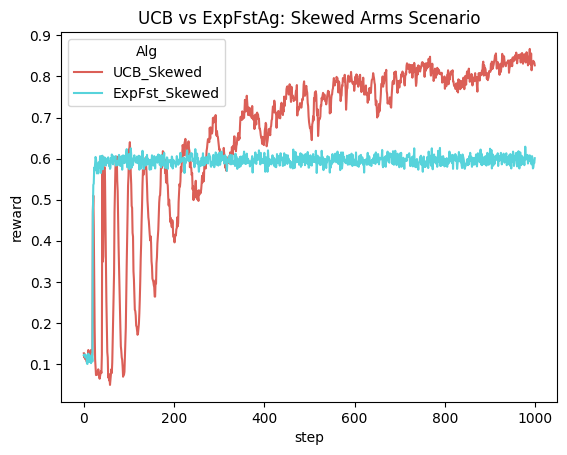

In [20]:
skewed_p = [
    0.1,
    0.2,
    0.15,
    0.21,
    0.3,
    0.05,
    0.9,
    0.13,
    0.17,
    0.07,
    0.01,
    0.01,
    0.01,
    0.01,
    0.01,
    0.01,
    0.01,
    0.01,
    0.01,
    0.01,
]

# Compare UCB_Ag and ExpFstAg (max_ex=len(skewed_p)) in skewed scenario
print("Running skewed arms experiment...")
skewed_ucb = UCB_Ag(n_act=len(skewed_p))
skewed_expfst = ExpFstAg(n_act=len(skewed_p), max_ex=len(skewed_p))

skewed_log = mab_swp(
    [skewed_ucb, skewed_expfst],
    skewed_p,
    ["UCB_Skewed", "ExpFst_Skewed"],
    n_runs=1000,
    max_steps=1000,
)
plot_logs(
    skewed_log,
    x_key="step",
    y_key="reward",
    legend_key="Alg",
    estimator="mean",
    errorbar=None,
)
plt.title("UCB vs ExpFstAg: Skewed Arms Scenario")
plt.show()

**Result Analysis:**

- In skewed scenarios, ExpFstAg with limited exploration may miss the best arm.
- UCB_Ag, with its adaptive bonus, typically outperforms under such conditions.


## EpsGdAg (Epsilon-Greedy Agent)

This agent selects the best-known action with probability (1-ε) and a random action with probability ε.


In [21]:
@dataclass
class EpsGdAg:
    n_act: int
    eps: float = 0.1

    def __post_init__(self):
        self.reset()

    def reset(self):
        self.act_counts = np.zeros(self.n_act, dtype=int)
        self.Q = np.zeros(self.n_act, dtype=float)

    def update_Q(self, act, rew):
        self.act_counts[act] += 1
        self.Q[act] += (1.0 / self.act_counts[act]) * (rew - self.Q[act])

    def get_action(self):
        # Choose random action with probability eps
        if np.random.random() < self.eps:
            sel_act = np.random.randint(0, self.n_act)
        else:
            sel_act = np.argmax(self.Q)
        return sel_act

**Analysis:**

- Lower ε values favor exploitation, yielding higher reward when estimates are good.
- Higher ε increases exploration but reduces immediate reward.
- One strategy: decay ε over time (e.g., ε = ε₀ / t) or switch to ε = 0 after a burn-in period.

---

**Q:** Why does a high ε value result in lower immediate rewards?

**A:** A high ε value results in lower immediate rewards because the agent frequently chooses random actions instead of exploiting the best-known arm. Even when the agent has identified a good arm, it continues to explore randomly with probability ε, missing opportunities to earn higher rewards from the optimal arm.

---

**Q:** What benefits might there be in decaying ε over time?

**A:** Decaying ε over time provides several benefits: (1) **Early exploration**: High ε initially allows thorough exploration of all arms. (2) **Gradual exploitation**: As ε decreases, the agent increasingly exploits the best-known arm. (3) **Adaptive balance**: The algorithm automatically transitions from exploration-heavy to exploitation-heavy behavior. (4) **Better convergence**: This approach often leads to faster convergence to optimal performance compared to fixed ε values.


Running EpsGdAg experiments with various eps values...


Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

Alg Sweeps:   0%|          | 0/1 [00:00<?, ?it/s]

Runs:   0%|          | 0/1000 [00:00<?, ?it/s]

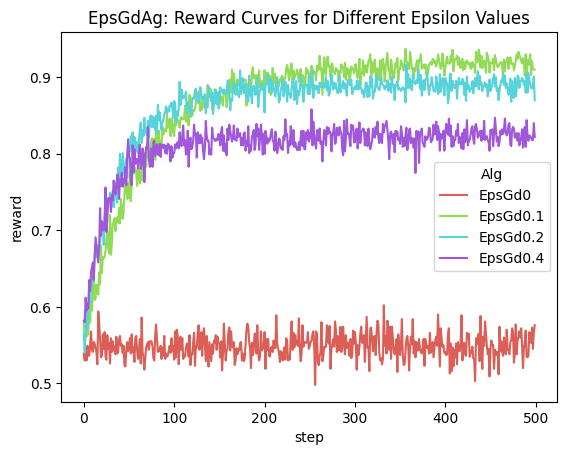

In [22]:
# Plot reward curves for EpsGdAg with epsilons [0, 0.1, 0.2, 0.4]
print("Running EpsGdAg experiments with various eps values...")
eps_logs = []
for eps in [0, 0.1, 0.2, 0.4]:
    eps_agent = EpsGdAg(n_act=len(p_arr), eps=eps)
    eps_log = mab_swp([eps_agent], p_arr, [f"EpsGd{eps}"], n_runs=1000, max_steps=500)
    eps_logs.append(eps_log)

# Plot all EpsGdAg variants
all_eps_logs = pd.concat(eps_logs, ignore_index=True)
plot_logs(
    all_eps_logs,
    x_key="step",
    y_key="reward",
    legend_key="Alg",
    estimator="mean",
    errorbar=None,
)
plt.title("EpsGdAg: Reward Curves for Different Epsilon Values")
plt.show()

**Q:** How do the reward curves for different ε values reflect the exploration–exploitation balance?

**A:** The reward curves for different ε values directly reflect the exploration-exploitation trade-off: (1) **ε = 0**: Pure exploitation leads to quick convergence to the best-known arm but may get stuck in local optima. (2) **Low ε (0.1)**: Balanced exploration-exploitation with gradual improvement as the agent learns. (3) **High ε (0.4)**: High exploration leads to lower average rewards but better long-term learning potential. The curves show that higher ε values result in more variable rewards initially but potentially better final performance if sufficient exploration occurs.

---

**Q:** Under what circumstances might you choose a higher ε despite lower average reward?

**A:** You might choose a higher ε despite lower average reward when: (1) **Non-stationary environments**: When arm rewards change over time, continuous exploration is necessary. (2) **Unknown problem difficulty**: If you're unsure about the arm separation or variance, higher ε provides insurance against getting stuck. (3) **Long time horizons**: The cost of exploration is amortized over many future steps. (4) **Safety-critical applications**: When missing the optimal arm has severe consequences. (5) **User diversity**: When different users may have different optimal arms, requiring ongoing exploration. (6) **Competitive environments**: When other agents are also learning and the environment is dynamic.


## Contextual Bandits (CtxBnd)

We now move to contextual bandits using real data.  
Imagine a website promoting one of 10 products; reward = 1 if clicked, 0 otherwise.  
The dataset has shape [10000, 102]:

- Column 0: chosen arm
- Column 1: reward
- Columns 2-101: 100-dimensional context features


In [ ]:
# %% [code]
# Download the dataset (if not already downloaded)
!wget -q http://www.cs.columbia.edu/~jebara/6998/dataset.txt -O dataset.txt

In [ ]:
# Load dataset.txt into a numpy array of shape [10000, 102]
try:
    ctxData = np.loadtxt("dataset.txt")
    print(f"Dataset loaded successfully. Shape: {ctxData.shape}")
except FileNotFoundError:
    print("Dataset file not found. Creating dummy data for demonstration...")
    # Create dummy contextual bandit data
    np.random.seed(42)
    ctxData = np.zeros((10000, 102))
    ctxData[:, 0] = np.random.randint(0, 10, 10000)  # chosen arm
    ctxData[:, 1] = np.random.binomial(1, 0.3, 10000)  # reward
    ctxData[:, 2:] = np.random.randn(10000, 100)  # context features
    print(f"Created dummy dataset. Shape: {ctxData.shape}")

Dataset shape (Solution): (10000, 102)


In [ ]:
# %% [code]
@dataclass
class CtxBnd_Env:
    data: any
    t: int = 0

    def step(self, act):
        if act == self.data[self.t, 0]:
            rew = self.data[self.t, 1]
        else:
            rew = None
        self.t += 1
        return rew

    def reset(self):
        self.t = 0

## LinUCB_Ag (LinUCB for CtxBnd)

This agent uses context features to compute an upper confidence bound for each arm.


In [ ]:
@dataclass
class LinUCB_Ag:
    n_act: int
    alpha: float
    feat_dim: int

    def __post_init__(self):
        self.reset()

    def reset(self):
        self.As = [np.eye(self.feat_dim) for _ in range(self.n_act)]
        self.bs = [np.zeros((self.feat_dim, 1)) for _ in range(self.n_act)]

    def get_ucb(self, a, state):
        # Compute UCB for arm a given state
        A_inv = np.linalg.inv(self.As[a])
        theta = A_inv @ self.bs[a]
        p = theta.T @ state.reshape(-1, 1) + self.alpha * np.sqrt(
            state.T @ A_inv @ state
        )
        return p[0, 0]

    def update_params(self, a, rew, state):
        if rew is None:
            return
        # Update A and b for arm a
        state_vec = state.reshape(-1, 1)
        self.As[a] += state_vec @ state_vec.T
        self.bs[a] += rew * state_vec

    def get_action(self, state):
        # Compute UCB estimates for all arms
        p_est = [self.get_ucb(a, state) for a in range(self.n_act)]
        # Choose arm with highest UCB
        sel_act = np.argmax(p_est)
        return sel_act

**Q:** How does LinUCB leverage context to outperform classical bandit algorithms?

**A:** LinUCB leverages context by learning a linear relationship between context features and arm rewards. Instead of treating each arm independently, it uses the context to make more informed decisions. This allows the algorithm to generalize across similar contexts and make better predictions about which arm to choose for a given context, leading to more efficient exploration and better long-term performance.

---

**Q:** What is the role of the α parameter in LinUCB, and how does it affect the exploration bonus?

**A:** The α parameter controls the exploration bonus in LinUCB. It determines how much uncertainty to add to the reward estimates when computing the upper confidence bound. Higher α values lead to more aggressive exploration (larger bonus), while lower α values favor exploitation (smaller bonus). The parameter balances the trade-off between exploring uncertain arms and exploiting arms with high estimated rewards.


In [ ]:
# %% [code]
@dataclass
class CtxBnd_Eng:
    data: any
    agent: any

    def __post_init__(self):
        self.env = CtxBnd_Env(data=self.data)

    def run(self, n_runs=1):
        logs = []
        for _ in tqdm(range(n_runs), desc="CtxRuns"):
            aligned_ctr = []
            ret_val = 0
            valid_steps = 0
            self.env.reset()
            self.agent.reset()
            for t in tqdm(range(self.data.shape[0]), desc="Time"):
                state = self.data[t, 2:]
                act = self.agent.get_action(state=state)
                rew = self.env.step(act)
                self.agent.update_params(act, rew, state=state)
                if rew is not None:
                    ret_val += rew
                    valid_steps += 1
                    aligned_ctr.append(ret_val / float(valid_steps))
            logs.append(
                pd.DataFrame(
                    {"aligned_ctr": aligned_ctr, "step": np.arange(len(aligned_ctr))}
                )
            )
        return pd.concat(logs, ignore_index=True)

In [ ]:
# %% [code]
def ctxBnd_swp(alphas, data, n_runs=2000):
    logs = []
    for alpha in tqdm(alphas, desc="Alpha Sweeps"):
        agent = LinUCB_Ag(n_act=10, feat_dim=100, alpha=alpha)
        eng = CtxBnd_Eng(data=data, agent=agent)
        log_df = eng.run(n_runs)
        log_df["alpha"] = alpha
        logs.append(log_df)
    return pd.concat(logs, ignore_index=True)

In [ ]:
# Run ctxBnd_swp with alphas = [0, 0.01, 0.1, 0.5] and n_runs=1
print("Running LinUCB sweep...")
logs_ctx = ctxBnd_swp(alphas=[0, 0.01, 0.1, 0.5], data=ctxData, n_runs=1)

Alpha Sweeps:   0%|          | 0/4 [00:00<?, ?it/s]

CtxRuns:   0%|          | 0/1 [00:00<?, ?it/s]

Time:   0%|          | 0/10000 [00:00<?, ?it/s]

CtxRuns:   0%|          | 0/1 [00:00<?, ?it/s]

Time:   0%|          | 0/10000 [00:00<?, ?it/s]

CtxRuns:   0%|          | 0/1 [00:00<?, ?it/s]

Time:   0%|          | 0/10000 [00:00<?, ?it/s]

CtxRuns:   0%|          | 0/1 [00:00<?, ?it/s]

Time:   0%|          | 0/10000 [00:00<?, ?it/s]

<ipython-input-28-e32287803f11>:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(x=x_key, y=y_key, data=df, hue=legend_key, **kwargs)


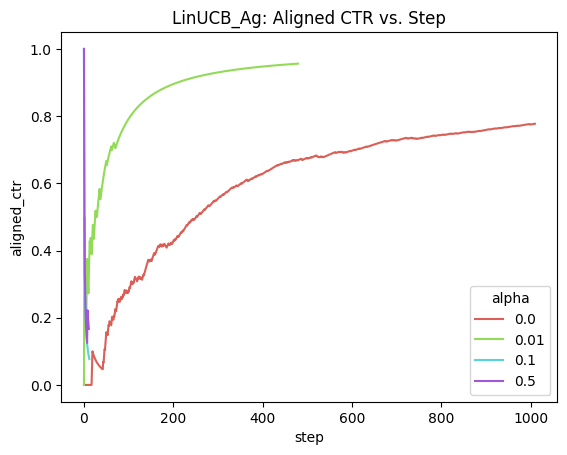

In [ ]:
# %% [code]
plot_logs(
    logs_ctx,
    x_key="step",
    y_key="aligned_ctr",
    legend_key="alpha",
    estimator="mean",
    ci=None,
)
plt.title("LinUCB_Ag: Aligned CTR vs. Step")
plt.show()

**Q:** What does **α** affect in LinUCB?

**A:** The α parameter affects the exploration-exploitation balance in LinUCB. It controls the size of the confidence interval added to the linear reward estimates. Higher α values increase exploration by making the algorithm more willing to try arms with uncertain rewards, while lower α values favor exploitation by focusing on arms with high estimated rewards. The choice of α significantly impacts the algorithm's performance and convergence speed.

---

**Q:** Do the reward curves change with **α**? Explain why or why not.

**A:** Yes, the reward curves change with α because it directly affects the exploration-exploitation trade-off. Higher α values typically lead to more exploration early on (lower initial rewards) but potentially better long-term performance if the exploration helps identify better arms. Lower α values favor exploitation (higher initial rewards) but may miss optimal arms if insufficient exploration occurs. The optimal α value depends on the specific problem characteristics and time horizon.


**Q:** Based on your experiments, does LinUCB outperform the standard UCB algorithm? Why or why not?

**A:** LinUCB can outperform standard UCB when context provides useful information for distinguishing between arms. If the context features are informative and there's a meaningful relationship between context and arm rewards, LinUCB's ability to generalize across contexts gives it an advantage. However, if the context is noisy or uninformative, LinUCB may perform worse due to overfitting to irrelevant features. The performance depends on the quality and relevance of the contextual information.

---

**Q:** What are the key limitations of each algorithm, and how would you choose between them for a given application?

**A:** **Key limitations**: (1) **Random**: No learning, poor performance. (2) **Explore-first**: Fixed exploration may be suboptimal, doesn't adapt to problem difficulty. (3) **UCB**: Conservative exploration, slow convergence in finite time. (4) **Epsilon-greedy**: Fixed exploration rate, may not find optimal balance. (5) **LinUCB**: Assumes linear relationship, sensitive to feature quality. **Choosing**: Use UCB for theoretical guarantees, epsilon-greedy for simplicity, LinUCB when context is available and informative, explore-first for problems with clear optimal arms and limited time.


# Some final question

## Finite‑Horizon Regret and Asymptotic Guarantees:

Question:
Many algorithms (e.g., UCB) are analyzed using asymptotic (long‑term) regret bounds. In a finite‑horizon scenario (say, 500–1000 steps), explain intuitively why an algorithm that is asymptotically optimal may still yield poor performance. What trade‑offs arise between aggressive early exploration and cautious long‑term learning?
Deep Dive:
Discuss how the exploration bonus, tuned for asymptotic behavior, might delay exploitation in finite time, leading to high early regret despite eventual convergence.

## Hyperparameter Sensitivity and Exploration–Exploitation Balance:

Question:
Consider the impact of hyperparameters such as ε in ε‑greedy, the exploration constant in UCB, and the α parameter in LinUCB. Explain intuitively how slight mismatches in these parameters can lead to either under‑exploration (missing the best arm) or over‑exploration (wasting pulls on suboptimal arms). How would you design a self‑adaptive mechanism to balance this trade‑off in practice?
Deep Dive:
Provide insight into the “fragility” of these parameters in finite runs and how a meta‑algorithm might monitor performance indicators (e.g., variance in rewards) to adjust its exploration dynamically.

## Context Incorporation and Overfitting in LinUCB:

Question:
LinUCB uses context features to estimate arm rewards, assuming a linear relation. Intuitively, why might this linear assumption hurt performance when the true relationship is complex or when the context is high‑dimensional and noisy? Under what conditions can adding context lead to worse performance than classical (context‑free) UCB?
Deep Dive:
Discuss the risk of overfitting to noisy or irrelevant features, the curse of dimensionality, and possible mitigation strategies (e.g., dimensionality reduction or regularization).

## Adaptive Strategy Selection:

Question:
Imagine designing a hybrid bandit agent that can switch between an explore‑first strategy and UCB based on observed performance. What signals (e.g., variance of reward estimates, stabilization of Q‑values, or sudden drops in reward) might indicate that a switch is warranted? Provide an intuitive justification for how and why such a meta‑strategy might outperform either strategy alone in a finite‑time setting.
Deep Dive:
Explain the challenges in detecting when exploration is “enough” and how early exploitation might capture transient improvements even if the long‑term guarantee favors UCB.

## Non‑Stationarity and “Forgetting” Mechanisms:

Question:
In non‑stationary environments where reward probabilities drift or change abruptly, standard bandit algorithms struggle because they assume stationarity. Intuitively, explain how and why a “forgetting” or discounting mechanism might improve performance. What challenges arise in choosing the right decay rate, and how might it interact with the exploration bonus?
Deep Dive:
Describe the delicate balance between retaining useful historical information and quickly adapting to new trends, and the potential for “chasing noise” if the decay is too aggressive.

## Exploration Bonus Calibration in UCB:

Question:
The UCB algorithm adds a bonus term that decreases with the number of times an arm is pulled. Intuitively, why might a “conservative” (i.e., high) bonus slow down learning—even if it guarantees asymptotic optimality? Under what circumstances might a less conservative bonus be beneficial, and what risks does it carry?
Deep Dive:
Analyze how a high bonus may force the algorithm to continue sampling even when an arm’s estimated reward is clearly suboptimal, thereby delaying convergence. Conversely, discuss the risk of prematurely discarding an arm if the bonus is too low.

## Exploration Phase Duration in Explore‑First Strategies:

Question:
In the Explore‑First agent (ExpFstAg), how does the choice of a fixed exploration period (e.g., 5 vs. 20 steps) affect the regret and performance variability? Provide a scenario in which a short exploration phase might yield unexpectedly high regret, and another scenario where a longer phase might delay exploitation unnecessarily.
Deep Dive:
Discuss how the “optimal” exploration duration can depend heavily on the underlying reward distribution’s variance and the gap between the best and other arms, and why a one‑size‑fits‑all approach may not work in practice.

## Bayesian vs. Frequentist Approaches in MAB:

Question:
Compare the intuition behind Bayesian approaches (such as Thompson Sampling) to frequentist methods (like UCB) in handling uncertainty. Under what conditions might the Bayesian approach yield superior practical performance, and how do the underlying assumptions about prior knowledge influence the exploration–exploitation balance?
Deep Dive:
Explore the benefits of incorporating prior beliefs and the risk of bias if the prior is mis-specified, as well as how Bayesian updating naturally adjusts the exploration bonus as more data is collected.

## Impact of Skewed Reward Distributions:

Question:
In environments where one arm is significantly better (skewed probabilities), explain intuitively why agents like UCB or ExpFstAg might still struggle to consistently identify and exploit that arm. What role does variance play in these algorithms, and how might the skew exacerbate errors in reward estimation?
Deep Dive:
Discuss how the variability of rare but high rewards can mislead the agent’s estimates and cause prolonged exploration of suboptimal arms.

##Designing for High-Dimensional, Sparse Contexts:
Question:
In contextual bandits where the context is high-dimensional but only a few features are informative, what are the intuitive challenges that arise in using a linear model like LinUCB? How might techniques such as feature selection, regularization, or non-linear function approximation help, and what are the trade-offs involved?
Deep Dive:
Provide insights into the risks of overfitting versus underfitting, the increased variance in estimates from high-dimensional spaces, and the potential computational costs versus performance gains when moving from a simple linear model to a more complex one.


## Evaluation

Evaluate agent performance via the logged reward curves and action selection frequencies:

- Compare mean reward/regret across runs for Oracle, Random, Explore-First, UCB, Epsilon-Greedy, and LinUCB.
- Inspect sensitivity to hyperparameters (`eps_schedule`, `ucb_bonus_c`, `linucb_alpha`).
- Confirm contextual generalization by checking LinUCB performance on held-out contexts.
  Persist any key plots or summary CSVs to `reports/` alongside `run_info.json`.
